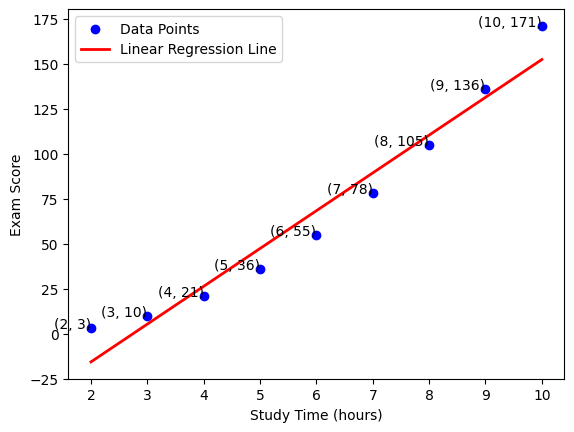

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# 假設數據 (Assuming the data)
X = np.array([ 2,  3,    4,   5,   6,   7,    8,    9,  10]).reshape(-1, 1)
y = np.array([ 3,  10,  21,  36,  55,  78,  105,  136, 171])

# 創建並訓練線性迴歸模型 (Create and train the linear regression model)
reg = LinearRegression()
reg.fit(X, y)

# 預測值 (Predicted values)
y_pred = reg.predict(X)

# 繪製散點圖和線性迴歸線 (Plot the scatter plot and linear regression line)
plt.scatter(X, y, color='blue', label='Data Points')
plt.plot(X, y_pred, color='red', linewidth=2, label='Linear Regression Line')
plt.xlabel('Study Time (hours)')
plt.ylabel('Exam Score')

for i, txt in enumerate(y):
    plt.text(X[i], y[i], f'({X[i][0]}, {y[i]})', fontsize=10, ha='right')


plt.legend()
plt.show()


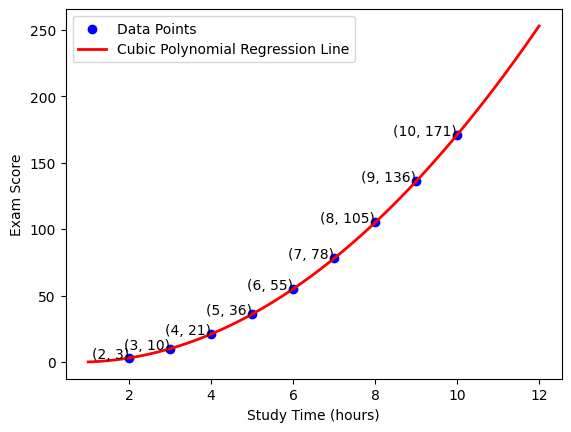

迴歸方程：y = 1.00 + -3.00x^1 + 2.00x^2


In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# 假設數據
X = np.array([ 2,  3,  4,  5,  6,  7,  8,  9, 10]).reshape(-1, 1)
y = np.array([  3,  10,  21,  36,  55,  78, 105, 136, 171])

# 創建並訓練二次多項式迴歸模型
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

reg = LinearRegression()
reg.fit(X_poly, y)

# 生成用於繪圖的數據點
X_plot = np.linspace(1, 12, 100).reshape(-1, 1)
X_plot_poly = poly.transform(X_plot)
y_plot = reg.predict(X_plot_poly)

# 繪製散點圖和二次多項式迴歸線
plt.scatter(X, y, color='blue', label='Data Points')
plt.plot(X_plot, y_plot, color='red', linewidth=2, label='Cubic Polynomial Regression Line')
plt.xlabel('Study Time (hours)')
plt.ylabel('Exam Score')

for i, txt in enumerate(y):
    plt.text(X[i], y[i], f'({X[i][0]}, {y[i]})', fontsize=10, ha='right')

plt.legend()
plt.show()

coefficients = reg.coef_
intercept = reg.intercept_
degree = poly.degree  # 獲取多項式次方數

equation = f"迴歸方程：y = {intercept:.2f}"
for i in range(1, degree + 1):
    equation += f" + {coefficients[i]:.2f}x^{i}"
    
print(equation)


X_poly= [[  1.   2.   4.]
 [  1.   3.   9.]
 [  1.   4.  16.]
 [  1.   5.  25.]
 [  1.   6.  36.]
 [  1.   7.  49.]
 [  1.   8.  64.]
 [  1.   9.  81.]
 [  1.  10. 100.]]
coefficients= [ 1. -3.  2.]
intercept= 0.9999999999998667
slopes= [-3.  2.]


To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  coefficients = np.linalg.lstsq(X_poly, y)[0]


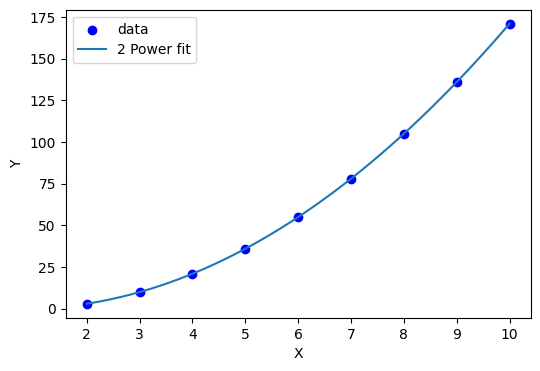

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# 不同的多项式次方数
degrees = [2]

plt.figure(figsize=(6, 4))
plt.scatter(X, y, color='blue', label='data')

for degree in degrees:
    # 創建多項式特徵。例如，對於 degree=2，這將包括 X 和 X^2。
    # 在多項式特徵矩陣前加上一個常數項列（所有元素都是1），這對應於截距。
    X_poly = np.column_stack([X** i for i in range(1, degree + 1)])
    X_poly = np.column_stack([np.ones(X_poly.shape[0]),X_poly])
    print("X_poly=",X_poly)
    
    # 使用最小二乘法計算多項式迴歸的係數。
    coefficients = np.linalg.lstsq(X_poly, y)[0]
    print("coefficients=",coefficients)

    # 從係數中提取截距。
    intercept = coefficients[0]
    print("intercept=",intercept)
    
    # 提取多項式的斜率（除了截距之外的所有係數）。
    slopes = coefficients[1:]
    print("slopes=",slopes)


    # 創建一組X值，用於繪製擬合的多項式曲線。
    X_plot = np.linspace(min(X), max(X), 100)
    
    # 使用計算出的係數計算對應的y值。
    y_plot = intercept + sum(slopes[i] * X_plot ** (i+1) for i in range(degree))
    
    # 繪製擬合的多項式曲線。
    plt.plot(X_plot, y_plot, label=f'{degree} Power fit')


plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()
